In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
np.random.seed(42)
plt.rcParams['figure.figsize'] = (8,4)


# Bias–Variance, Regularization, MLE, MAP, and Cross-Validation


**Instructions:** Fill only the code in the `TODO` blocks. After finishing each exercise, write your short conceptual answers in the provided **Answer** cell. Use `sklearn` for all models (`PolynomialFeatures`, `LinearRegression`, `Ridge`). 


### Quick glossary

Before we start, here are compact definitions you’ll see referenced a lot. Read carefully.

* **Model bias (statistical bias):** The systematic error introduced by approximating a real-world problem (which may be complex) by a simplified model. Formally, if $\hat f$ is an estimator, bias at $x$ is $\mathrm{Bias}(\hat f(x)) = \mathbb{E}[\hat f(x)] - f(x).$
* **Model variance:** The variability of $\hat f(x)$ across different training sets — i.e., $\mathrm{Var}(\hat f(x)) = \mathbb{E}[(\hat f(x) - \mathbb{E}[\hat f(x)])^2].$
* **Noise (irreducible error):** Random component in the data generation process, e.g., $\varepsilon \sim N(0,\sigma^2)$. This cannot be reduced by better models or more data.
* **MLE (Maximum Likelihood Estimator):** The parameter value that maximizes the likelihood $p(D \mid \theta)$.
* **MAP (Maximum A Posteriori):** The parameter value that maximizes the posterior $p(\theta \mid D) \propto p(D\mid\theta)p(\theta)$. It combines likelihood and a prior.
* **Prior:** A probability distribution representing beliefs about parameters before seeing the data. E.g., a Gaussian prior ($\theta \sim N(\mu_0, \tau^2)$).
* **Posterior:** Updated belief after seeing data, $p(\theta \mid D)$.
* **Regularization:** Penalizing large parameters to keep models simpler; L2 regularization (Ridge) corresponds to a Gaussian prior on weights.
* **Degree of freedom / consuming a degree of freedom:** Roughly, each parameter estimated from data “uses up” information from the data; adding a parameter increases model complexity and can increase variance.
* **Cross-validation (CV):** A procedure to estimate out-of-sample performance by repeatedly splitting data into training and validation folds.


# Section1: Bias–Variance & effect of noise

### Why (motivation)

Students commonly ask: *Why does a more complex model sometimes produce worse test performance?* The answer: adding complexity can reduce bias but often increases variance; if noise or sample size is unfavorable, variance dominates and test performance deteriorates.

We study a synthetic DGP so we have ground truth. This helps you see bias and variance directly rather than guessing.

### What (concept & details)

* Data generating process (DGP):
  $x_i \sim \text{Uniform}(-1,1),\; y_i = f(x_i) + \varepsilon_i,\; f(x)=\sin(3x),\; \varepsilon_i \sim N(0, \sigma^2).$
* **Noise effect intuition:** Higher $\sigma$ increases the irreducible error and makes overfitting worse: high-degree models will fit noisy fluctuations that are not part of $f(x)$, increasing test error.
* **What to observe:** For fixed sample size:

  * Low-degree models have high bias but low variance => underfitting (large train & test error).
  * High-degree models have low bias but high variance => can overfit; they may have very low train error but high test error, especially when noise is high.

### How (implementation)



=== sigma= 0.05 n= 50 ===
deg 1 train_mse 0.157 test_mse 0.1732
deg 3 train_mse 0.0053 test_mse 0.0034
deg 9 train_mse 0.0014 test_mse 0.0016


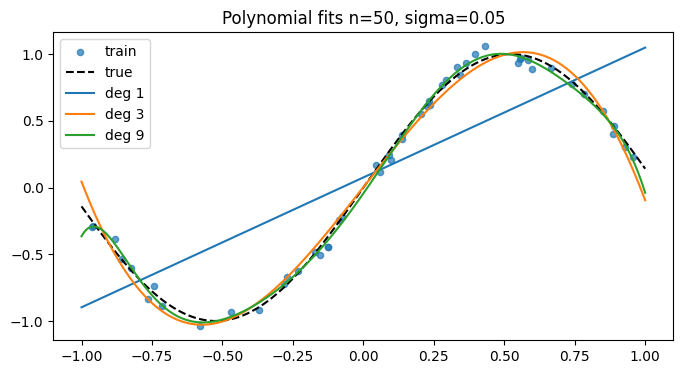


=== sigma= 0.1 n= 50 ===
deg 1 train_mse 0.1679 test_mse 0.1724
deg 3 train_mse 0.0121 test_mse 0.0039
deg 9 train_mse 0.0056 test_mse 0.0063


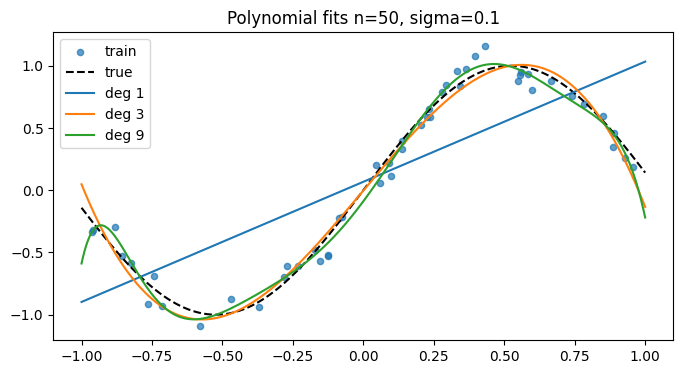


=== sigma= 0.3 n= 50 ===
deg 1 train_mse 0.2543 test_mse 0.1707
deg 3 train_mse 0.0816 test_mse 0.009
deg 9 train_mse 0.0505 test_mse 0.0566


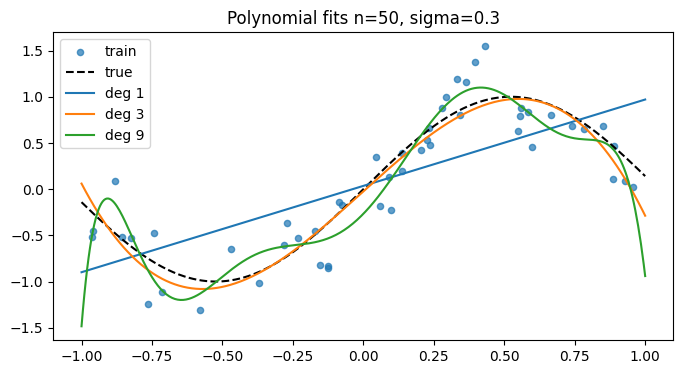

In [2]:

def true_function(x):
    return np.sin(3 * x).ravel()

def generate_data(n=50, noise_std=0.2, seed=None):
    rng = np.random.RandomState(seed) if seed is not None else np.random
    X = rng.uniform(-1,1,size=n).reshape(-1,1)
    y_true = true_function(X)
    y = y_true + rng.normal(0, noise_std, size=n)
    return X, y, y_true

def fit_poly_and_report(X_train, y_train, X_grid, y_true_grid, degree):
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_grid = model.predict(X_grid)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_true_grid, y_pred_grid)
    return model, train_mse, test_mse, y_pred_grid

# Demo
sigmas = [0.05, 0.1, 0.3]
n = 50; degrees = [1,3,9]
X_grid = np.linspace(-1,1,400).reshape(-1,1); y_true_grid = true_function(X_grid)
for s in sigmas:
    X_train, y_train, _ = generate_data(n,s, seed=0)
    print('\n=== sigma=',s,'n=',n,'===')
    for d in degrees:
        model, tr_mse, te_mse, y_pred = fit_poly_and_report(X_train, y_train, X_grid, y_true_grid, d)
        print('deg',d,'train_mse',round(tr_mse,4),'test_mse',round(te_mse,4))

    plt.scatter(X_train, y_train, s=20, alpha=0.7, label='train')
    plt.plot(X_grid, y_true_grid, '--', color='k', label='true')
    for d in degrees:
        _, tr_mse, te_mse, y_pred = fit_poly_and_report(X_train, y_train, X_grid, y_true_grid, d)
        plt.plot(X_grid, y_pred, label=f'deg {d}')
    plt.legend(); plt.title(f'Polynomial fits n={n}, sigma={s}'); plt.show()


**Interpretation:** Degree-9 fits often have very low train MSE but higher test MSE when noise is large — classic overfitting. More data reduces variance and narrows the train/test gap.


# Section2: Model complexity & data quantity

### Why

Students must learn that **more data** often saves us from overfitting: a complex model can be safe if enough data is available. The question: *how many data points are "enough"?* We approach this empirically.

### What (concept)

* For a fixed model complexity, variance tends to drop as sample size grows. Thus the test error of high-degree models often decreases with sample size.
* The interplay: bias decreases with complexity; variance increases. More data reduces variance, potentially tipping the balance in favor of complex models.

### How (implementation)


n 10 train_mse 0.0 test_mse 99236.1106
n 25 train_mse 0.0092 test_mse 10.0349
n 100 train_mse 0.0109 test_mse 0.0013


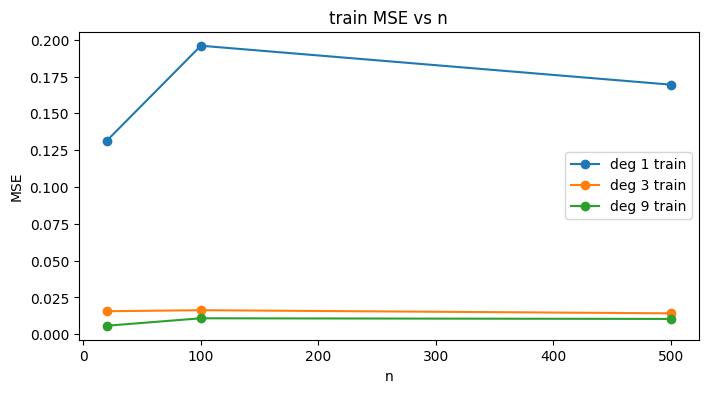

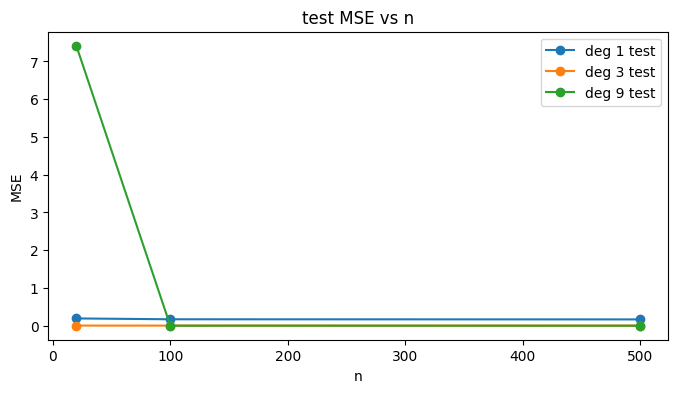

In [3]:

def experiment_degree9_sizes(noise=0.1):
    for n in [10,25,100]:
        X_train, y_train, _ = generate_data(n, noise, seed=n)
        _, tr_mse, te_mse, _ = fit_poly_and_report(X_train, y_train, X_grid, y_true_grid, degree=9)
        print('n',n,'train_mse',round(tr_mse,4),'test_mse',round(te_mse,4))

def experiment_mse_vs_n(degrees=[1,3,9], ns=[20,100,500], noise=0.1):
    results = {}
    for d in degrees:
        results[d] = {'train':[], 'test':[]}
        for n in ns:
            X_train, y_train, _ = generate_data(n, noise, seed=n)
            _, tr_mse, te_mse, _ = fit_poly_and_report(X_train, y_train, X_grid, y_true_grid, degree=d)
            results[d]['train'].append(tr_mse)
            results[d]['test'].append(te_mse)
    # plot
    for metric in ['train','test']:
        for d in degrees:
            plt.plot(ns, results[d][metric], marker='o', label=f'deg {d} {metric}')
        plt.xlabel('n'); plt.ylabel('MSE'); plt.title(metric + ' MSE vs n'); plt.legend(); plt.show()

experiment_degree9_sizes(noise=0.1)
experiment_mse_vs_n()


**Interpretation:** As n grows, test MSE for complex models usually drops — variance reduces, enabling safe higher complexity.


# Section3: Effect of K in K-Fold CV 

### Why

Common question: *Should I pick k=5, k=10, or LOOCV?* The theory: k trades bias vs variance in the CV estimate itself. You need to *see* how the CV estimate's variance behaves across different k values.

### What (concept & explanation)

* **Lower k (e.g., 2):** validation sets are large; you compute fewer folds. This tends to produce more variable model-selection outcomes (because each fold is more different).
* **Higher k (e.g., 10 or LOOCV):** validation sets are small; the CV estimate may have lower bias but can have *higher variance* of the estimate in some settings and is computationally heavier.
* For model selection stability, k=5 or 10 are commonly used as practical choices.

### How (implementation)


In [4]:

def k_fold_mse_manual(X, y, degree, k=5, seed=None):
    n = len(X)
    rng = np.random.RandomState(seed) if seed is not None else np.random
    idx = rng.permutation(n)
    folds = np.array_split(idx, k)
    mses = []
    for i in range(k):
        val = folds[i]
        train = np.hstack([f for j,f in enumerate(folds) if j!=i])
        model = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression()).fit(X[train], y[train])
        mses.append(mean_squared_error(y[val], model.predict(X[val])))
    return np.mean(mses)

X_sample, y_sample, _ = generate_data(100,0.2, seed=10)
for k in [2,5,10]:
    scores = [k_fold_mse_manual(X_sample,y_sample,d,k=k, seed=10) for d in range(1,16)]
    print('k=',k,'best degree=', int(np.argmin(scores)+1))


k= 2 best degree= 3
k= 5 best degree= 5
k= 10 best degree= 5


**Interpretation:** Lower k (like 2) tends to higher bias in selection but lower variance of estimate; larger k reduces bias but can increase variance of selection. k=5 or 10 are practical defaults.


# Section4: MLE vs MAP (Prior misspecification)

### Why

Understanding difference between MLE and MAP is core for statistical modeling and for interpreting regularization Bayesianly. Beliefs (priors) can help or harm: we must see that with small data, a sensible prior reduces MSE but a bad prior increases bias and can hurt.

### What (concept)

* **MLE:** chooses the parameter that maximizes data likelihood. For Gaussian mean with known variance, MLE is simply the sample mean.
* **MAP:** chooses the parameter that maximizes the posterior ($p(\theta|D) \propto p(D|\theta)p(\theta)$). With Gaussian likelihood and Gaussian prior ($\theta \sim N(\mu_0, \tau^2)$), MAP has **closed form**: it is a weighted average of the prior mean and sample mean:
  
  $\hat\theta_{\text{MAP}} = \frac{(n/\sigma^2)\bar{x} + (1/\tau^2)\mu_0}{(n/\sigma^2) + (1/\tau^2)}.$
  
  So MAP pulls the estimate toward $\mu_0$ — this is **bias** introduced by the prior — but reduces variance.
* **Prior misspecification:** If $\mu_0$ is near the truth, MAP helps (reduces MSE). If $\mu_0$ is far from truth and $\tau^2$ is small (strong prior), MAP can substantially increase bias and hurt MSE. With increasing $n$, the likelihood dominates and MAP $\to$ MLE.

**What 'biased' means here:** An estimator $\hat\theta$ is biased if $\mathbb{E}[\hat\theta] \ne \theta_{\text{true}}$. For MAP, bias can come from prior pulling estimate away from true parameter.

### How (implementation) 


In [5]:

def mle_mean(data):
    return np.mean(data)

def map_mean(data, mu0=0.0, sigma_p=1.0, sigma=1.0):
    n = len(data); sample_mean = np.mean(data)
    return ((n/(sigma**2)) * sample_mean + (1/(sigma_p**2))*mu0) / ((n/(sigma**2)) + (1/(sigma_p**2)))

def compare_mle_map(true_mu=3.0, trials=1000):
    priors = [(0,0.2),(0,1),(0,5),(2,1),(3,1)]
    rows = []
    for mu0,sigma_p in priors:
        mse_mle=[]; mse_map=[]
        for _ in range(trials):
            data = np.random.normal(true_mu,1.0,5)
            mle = np.mean(data)
            map_est = map_mean(data, mu0=mu0, sigma_p=sigma_p, sigma=1.0)
            mse_mle.append((mle-true_mu)**2); mse_map.append((map_est-true_mu)**2)
        rows.append((mu0, sigma_p, np.mean(mse_mle), np.mean(mse_map)))
    return pd.DataFrame(rows, columns=['mu0','sigma_p','MSE_MLE','MSE_MAP'])

df = compare_mle_map(); display(df)


,mu0,sigma_p,MSE_MLE,MSE_MAP
0,0,0.2,0.198967,6.250859
1,0,1.0,0.191814,0.391432
2,0,5.0,0.194636,0.191627
3,2,1.0,0.202139,0.163565
4,3,1.0,0.189745,0.131767


**Interpretation:** MAP can lower MSE with a helpful prior (small n). But a strong wrong prior increases bias and harms MSE. As n grows, likelihood dominates and MLE and MAP converge.


# Section5: MAP as Regularization (Ridge equivalence)

### Why

In many ML models we add penalties (regularization) to avoid extreme weights. Bayesian interpretation: an L2 penalty (Ridge) corresponds to a Gaussian prior on coefficients. This link helps choose penalty strength based on prior belief about weights and noise level.

### What (concept & explanation)

* For linear regression ($y \sim N(X\beta, \sigma^2 I)$) and prior ($\beta \sim N(0, \tau^2 I)$), the posterior mode solves:
  
  $\hat\beta_{\text{MAP}} = \arg\min_\beta \frac{1}{2\sigma^2} |y - X\beta|^2 + \frac{1}{2\tau^2}|\beta|^2.$
  
  Multiply by $2\sigma^2$ and set $\alpha = \sigma^2/\tau^2$, this is:
  
  $\arg\min_\beta |y-X\beta|^2 + \alpha |\beta|^2$
  
  which is Ridge regression with penalty $\alpha$.
* **Interpretation:** Larger $\alpha$ corresponds to smaller prior variance ($\tau^2$) (strong belief that coefficients are near zero), so stronger shrinkage.

### How (implementation)


In [6]:

def make_linear(n=120, p=20, k=5, noise=0.5, seed=None):
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random
    X = rng.normal(size=(n,p))
    beta = np.zeros(p); beta[:k] = np.linspace(1.0, 0.5, k)
    y = X.dot(beta) + rng.normal(0, noise, size=n)
    return X, y, beta

X, y, true_beta = make_linear(n=120,p=20,k=5,noise=0.5, seed=0)
Xtr, Xte, ytr, yte = train_test_split(X,y,test_size=0.3, random_state=0)
print('Liniear regression coef norm', np.linalg.norm(LinearRegression().fit(Xtr,ytr).coef_))
for alpha in [0.01,0.1,1.0,10.0,50.0,1000.0]:
    r = Ridge(alpha=alpha).fit(Xtr,ytr)
    print('alpha',alpha,'coef norm',np.linalg.norm(r.coef_),'test MSE', mean_squared_error(yte, r.predict(Xte)))
# compute implied tau2 for example alphas (approx): tau2 = noise^2 / alpha
noise_var = 0.5**2
for alpha in [0.01,0.1,1.0,10.0,50.0,1000.0]:
    tau2 = noise_var / alpha
    print('alpha',alpha,'implied tau2',tau2)


Liniear regression coef norm 1.800433693520696
alpha 0.01 coef norm 1.8002097863738264 test MSE 0.36832546145133976
alpha 0.1 coef norm 1.798198313243452 test MSE 0.36814092736714804
alpha 1.0 coef norm 1.7784396480197555 test MSE 0.36683610448353204
alpha 10.0 coef norm 1.6093723356918612 test MSE 0.3907212081295628
alpha 50.0 coef norm 1.1655549380956722 test MSE 0.702983209521695
alpha 1000.0 coef norm 0.17266721915969124 test MSE 2.3804866485719662
alpha 0.01 implied tau2 25.0
alpha 0.1 implied tau2 2.5
alpha 1.0 implied tau2 0.25
alpha 10.0 implied tau2 0.025
alpha 50.0 implied tau2 0.005
alpha 1000.0 implied tau2 0.00025


**Interpretation:** α = σ^2/τ^2 connects penalty strength α to prior variance τ^2. Use this to interpret/choose α in principled way.
